# Phase 1B — Transmission Cleaning

Turn raw OSM transmission features into a pandapower-ready bus/line CSV pair.

**Pipeline:**
1. Filter to transmission voltage lines + all `power=cable` (submarine)
2. Explode multilines, repair geometry
3. Extract endpoints → cluster within 55 m → bus
4. Match clusters to substations within 500 m → use substation as bus; else synthetic tower bus
5. Spatial join buses → province/island
6. Build lines table with from_bus/to_bus, length_km, voltage_kv, impedance per voltage class
7. Flag submarine cables with XLPE impedance

**Outputs:** `data/processed/buses.csv`, `data/processed/lines.csv`

In [1]:
from pathlib import Path
import re
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from shapely.geometry import Point
from shapely import STRtree

RAW = Path('../backend/data/raw/visayas_power_raw.geojson')
BOUND_DIR = Path('../backend/data/boundaries')
PROC_DIR = Path('../backend/data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

WGS = 'EPSG:4326'
UTM = 'EPSG:32651'   # UTM 51N for Visayas
SNAP_M = 55          # snap tolerance, meters
SUB_MATCH_M = 500    # max distance for endpoint→substation match

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [2]:
raw = gpd.read_file(RAW)
provinces = gpd.read_file(BOUND_DIR / 'psgc_provinces.geojson')
islands = gpd.read_file(BOUND_DIR / 'visayas_islands.geojson')
print(f'OSM features: {len(raw)} | provinces: {len(provinces)} | islands: {len(islands)}')

OSM features: 19607 | provinces: 16 | islands: 9


## §1 — Voltage parsing & transmission filter

Reuses the parser from the coverage audit. Transmission set = voltage ≥ 60 kV; all `power=cable` retained regardless of tag (submarine cables often missing voltage).

In [3]:
def parse_voltage(v) -> list[int]:
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return []
    out = []
    for part in re.split(r'[;,/]', str(v)):
        m = re.search(r'\d+', part)
        if not m:
            continue
        n = int(m.group())
        kv = n / 1000 if n >= 1000 else n
        if 0.4 <= kv <= 1000:
            out.append(int(round(kv)))
    return out

raw['voltage_kv_list'] = raw['voltage'].apply(parse_voltage)
raw['voltage_kv_max'] = raw['voltage_kv_list'].apply(lambda xs: max(xs) if xs else np.nan)

is_line   = raw['power'].isin(['line', 'cable']) & raw.geometry.geom_type.isin(['LineString', 'MultiLineString'])
is_tx_v   = raw['voltage_kv_max'] >= 60
is_cable  = raw['power'] == 'cable'

lines_raw = raw[is_line & (is_tx_v | is_cable)].copy()
print(f'Selected lines: {len(lines_raw)}')
print(lines_raw[['power']].value_counts())

Selected lines: 396
power
line     352
cable     44
Name: count, dtype: int64


## §2 — Geometry repair

Explode multi-line geometries; drop zero-length segments. Project to UTM 51N for metric ops.

In [4]:
lines_x = lines_raw.explode(index_parts=False).reset_index(drop=True)
lines_x = lines_x[lines_x.geometry.geom_type == 'LineString']
lines_x = lines_x[~lines_x.geometry.is_empty].copy()
lines_x['osm_id'] = lines_x.index.astype(str)

lines_m = lines_x.to_crs(UTM)
lines_m['length_m'] = lines_m.geometry.length
lines_m = lines_m[lines_m['length_m'] > 1.0].copy()  # drop degenerate < 1 m
print(f'After explode/clean: {len(lines_m)} line segments')
print(f'Length stats (m): min={lines_m["length_m"].min():.1f}, '
      f'median={lines_m["length_m"].median():.1f}, '
      f'max={lines_m["length_m"].max():.1f}, '
      f'sum={lines_m["length_m"].sum()/1000:.0f} km')

After explode/clean: 396 line segments
Length stats (m): min=4.8, median=1036.5, max=257918.1, sum=7849 km


## §3 — Extract endpoints

Each line contributes 2 endpoint records: `(line_idx, side='start'|'end', point)`. These are the candidate bus locations.

In [5]:
ep_records = []
for i, geom in enumerate(lines_m.geometry.values):
    coords = list(geom.coords)
    ep_records.append({'line_idx': i, 'side': 'start', 'pt': Point(coords[0])})
    ep_records.append({'line_idx': i, 'side': 'end',   'pt': Point(coords[-1])})
endpoints = pd.DataFrame(ep_records)
print(f'Total endpoints: {len(endpoints)} (= 2 × {len(lines_m)} lines)')

Total endpoints: 792 (= 2 × 396 lines)


## §4 — Substation prep

Project substations to UTM. Some are points, some polygons; representative_point gives a stable single coord.

In [6]:
subs_raw = raw[raw['power'] == 'substation'].copy()
subs_m = subs_raw.to_crs(UTM)

def sub_label(row, fallback_idx):
    name = row.get('name')
    if isinstance(name, str) and name.strip():
        slug = re.sub(r'[^a-zA-Z0-9]+', '_', name.strip()).strip('_').lower()
        return f'sub_{slug}_{fallback_idx}'
    return f'sub_osm_{fallback_idx}'

subs_m = subs_m.reset_index(drop=True)
subs_m['bus_id'] = [sub_label(r, i) for i, r in subs_m.iterrows()]
subs_m['rep_pt'] = subs_m.geometry.representative_point()
subs_m['voltage_kv_sub'] = subs_m['voltage_kv_list'].apply(
    lambda xs: max(xs) if isinstance(xs, list) and xs else np.nan)
print(f'Substations: {len(subs_m)} | named: {(subs_m["name"].notna()).sum()}')

Substations: 121 | named: 95


## §5 — Cluster endpoints via NetworkX connected components

Build a graph where:
- Each endpoint is a node `('ep', i)`
- Each substation is a virtual node `('sub', j)`
- Edge between two endpoints within `SNAP_M` (55 m)
- Edge between substation and any endpoint within `SUB_MATCH_M` (500 m) of the substation polygon

Connected components → buses. Components containing a substation node take that substation's bus_id; the rest become synthetic tower buses.

In [7]:
ep_geoms = endpoints['pt'].tolist()
ep_tree = STRtree(ep_geoms)

G = nx.Graph()
G.add_nodes_from((('ep', i) for i in range(len(ep_geoms))))

# Endpoint-endpoint edges within SNAP_M
pairs = ep_tree.query(ep_geoms, predicate='dwithin', distance=SNAP_M)
# query() returns (input_idx_array, tree_idx_array)
for a, b in zip(pairs[0], pairs[1]):
    if a < b:  # avoid self loops and duplicates
        G.add_edge(('ep', int(a)), ('ep', int(b)))
print(f'Endpoint-endpoint edges added: {G.number_of_edges()}')

Endpoint-endpoint edges added: 2382


In [8]:
# Substation-endpoint edges within SUB_MATCH_M of substation polygon
sub_geoms = subs_m.geometry.tolist()
sub_buffered = [g.buffer(SUB_MATCH_M) for g in sub_geoms]
sub_tree = STRtree(sub_buffered)

ep_arr = np.array(ep_geoms, dtype=object)
ep_to_sub_pairs = sub_tree.query(ep_geoms, predicate='intersects')
# (ep_idx_arr, sub_idx_arr) where ep falls in substation's buffered region
for ep_idx, sub_idx in zip(ep_to_sub_pairs[0], ep_to_sub_pairs[1]):
    G.add_edge(('ep', int(ep_idx)), ('sub', int(sub_idx)))
print(f'Total edges after substation linkage: {G.number_of_edges()}')
print(f'Nodes: {G.number_of_nodes()} '
      f'({sum(1 for n in G.nodes if n[0]=="ep")} endpoints + '
      f'{sum(1 for n in G.nodes if n[0]=="sub")} substations)')

Total edges after substation linkage: 3198
Nodes: 860 (792 endpoints + 68 substations)


In [9]:
# Add isolated substation nodes (no endpoints attached) so they still become buses
for i in range(len(subs_m)):
    G.add_node(('sub', i))

components = list(nx.connected_components(G))
print(f'Connected components: {len(components)}')
ep_to_cluster = {}
cluster_to_sub_idx = {}
for ci, comp in enumerate(components):
    sub_idxs = [n[1] for n in comp if n[0] == 'sub']
    ep_idxs  = [n[1] for n in comp if n[0] == 'ep']
    for ei in ep_idxs:
        ep_to_cluster[ei] = ci
    if sub_idxs:
        # Use the first substation in the component (typical: 1 component contains 1 substation)
        cluster_to_sub_idx[ci] = sub_idxs[0]

# Stats: how many components have multiple substations? (would indicate snap pulled them together)
multi_sub_components = [c for c in components if sum(1 for n in c if n[0]=='sub') > 1]
print(f'Components with >1 substation (over-merged): {len(multi_sub_components)}')

Connected components: 213
Components with >1 substation (over-merged): 9


## §6 — Build bus DataFrame

For each component, the bus location is:
- the substation's representative point (if component has substation)
- else the mean of endpoint coords

In [10]:
bus_rows = []
tower_counter = 0
for ci, comp in enumerate(components):
    sub_idxs = [n[1] for n in comp if n[0] == 'sub']
    ep_idxs  = [n[1] for n in comp if n[0] == 'ep']

    if sub_idxs:
        srow = subs_m.iloc[sub_idxs[0]]
        bus_id = srow['bus_id']
        bus_type = 'substation'
        geom = srow['rep_pt']
        sub_voltage = srow['voltage_kv_sub']
        name = srow.get('name') if isinstance(srow.get('name'), str) else bus_id
    else:
        tower_counter += 1
        bus_id = f'tower_{tower_counter:04d}'
        bus_type = 'tower'
        pts = [ep_geoms[ei] for ei in ep_idxs]
        if pts:
            geom = Point(np.mean([p.x for p in pts]), np.mean([p.y for p in pts]))
        else:
            continue  # skip empty component (shouldn't happen)
        sub_voltage = np.nan
        name = bus_id

    bus_rows.append({
        'cluster_id': ci,
        'bus_id': bus_id,
        'name': name,
        'bus_type': bus_type,
        'voltage_kv_hint': sub_voltage,
        'geometry': geom,
    })

buses_m = gpd.GeoDataFrame(bus_rows, crs=UTM)
print(f'Total buses: {len(buses_m)} (substations: {(buses_m["bus_type"]=="substation").sum()}, '
      f'towers: {(buses_m["bus_type"]=="tower").sum()})')

Total buses: 213 (substations: 111, towers: 102)


## §7 — Province/island assignment via sjoin

In [11]:
MAX_OFFSHORE_KM = 5  # cable terminals just offshore get snapped; anything farther is non-Visayas

buses_wgs = buses_m.to_crs(WGS)
buses_wgs = gpd.sjoin(
    buses_wgs, provinces[['psgc_code', 'province', 'island_name', 'geometry']],
    how='left', predicate='within'
).drop(columns=['index_right'])

n_unassigned = buses_wgs['province'].isna().sum()
print(f'Buses without province on first sjoin: {n_unassigned}')
if n_unassigned:
    unassigned_m = buses_wgs[buses_wgs['province'].isna()].to_crs(UTM).copy()
    prov_m = provinces[['psgc_code', 'province', 'island_name', 'geometry']].to_crs(UTM)
    nearest = gpd.sjoin_nearest(
        unassigned_m[['cluster_id', 'geometry']], prov_m,
        how='left', distance_col='snap_dist_m',
    )
    nearest_map = nearest.set_index('cluster_id')[
        ['psgc_code', 'province', 'island_name', 'snap_dist_m']
    ]
    in_range  = nearest_map[nearest_map['snap_dist_m'] <= MAX_OFFSHORE_KM * 1000]
    out_range = nearest_map[nearest_map['snap_dist_m']  > MAX_OFFSHORE_KM * 1000]
    print(f'  Within {MAX_OFFSHORE_KM} km of a Visayas province (offshore terminals): {len(in_range)}')
    print(f'  Beyond {MAX_OFFSHORE_KM} km (non-Visayas - Luzon/Mindanao/Masbate): {len(out_range)}')
    for cid, row in in_range.iterrows():
        mask = buses_wgs['cluster_id'] == cid
        buses_wgs.loc[mask, ['psgc_code', 'province', 'island_name']] = (
            row['psgc_code'], row['province'], row['island_name']
        )
    if len(out_range):
        drop_clusters = set(out_range.index)
        buses_wgs = buses_wgs[~buses_wgs['cluster_id'].isin(drop_clusters)].copy()
        print(f'    Dropped {len(drop_clusters)} non-Visayas buses; lines referencing them will be dropped in section 8.')

print(f'Final bus count after non-Visayas drop: {len(buses_wgs)}')
print('Province distribution:')
print(buses_wgs['province'].value_counts())

Buses without province on first sjoin: 27
  Within 5 km of a Visayas province (offshore terminals): 0
  Beyond 5 km (non-Visayas - Luzon/Mindanao/Masbate): 27
    Dropped 27 non-Visayas buses; lines referencing them will be dropped in section 8.
Final bus count after non-Visayas drop: 186
Province distribution:
province
Cebu                 54
Leyte                37
Negros Occidental    23
Eastern Samar        17
Negros Oriental      15
Bohol                14
Samar                 9
Southern Leyte        8
Northern Samar        5
Iloilo                2
Biliran               1
Siquijor              1
Name: count, dtype: int64


## §8 — Build lines DataFrame

For each segment: map its start/end endpoints to clusters → bus_ids.

In [12]:
cluster_to_bus = dict(zip(buses_m['cluster_id'], buses_m['bus_id']))

# Per-endpoint cluster lookup
endpoints['cluster_id'] = endpoints.index.map(ep_to_cluster)
endpoints['bus_id'] = endpoints['cluster_id'].map(cluster_to_bus)

# Pivot: for each line_idx, get start_bus and end_bus
start_bus = endpoints[endpoints['side'] == 'start'].set_index('line_idx')['bus_id']
end_bus   = endpoints[endpoints['side'] == 'end'].set_index('line_idx')['bus_id']

lines_out = lines_m.copy().reset_index(drop=True)
lines_out['from_bus'] = lines_out.index.map(start_bus)
lines_out['to_bus']   = lines_out.index.map(end_bus)

n_loops = (lines_out['from_bus'] == lines_out['to_bus']).sum()
print(f'Self-loops (snapped both endpoints to same bus): {n_loops}')
lines_out = lines_out[lines_out['from_bus'] != lines_out['to_bus']].copy()
print(f'Lines after self-loop removal: {len(lines_out)}')

Self-loops (snapped both endpoints to same bus): 176
Lines after self-loop removal: 220


## §9 — Voltage + impedance assignment

**Line voltage:** max of parsed values.
**Impedance per voltage class** (overhead AC, typical Visayas values — refine when real data arrives):

| Voltage | r Ω/km | x Ω/km | max kA |
|---|---|---|---|
| 230 kV | 0.05 | 0.40 | 0.90 |
| 138 kV | 0.08 | 0.40 | 0.70 |
| 69 kV  | 0.15 | 0.40 | 0.50 |
| 60 kV  | 0.18 | 0.42 | 0.45 |
| 350 kV (HVDC stand-in) | 0.04 | 0.30 | 1.20 |

**Submarine (`power=cable`)** overrides regardless of voltage: r=0.0754, x=0.121, max kA=0.645 (plan v2 §submarine note).

In [13]:
OVERHEAD_IMPEDANCE = {
    60:  (0.18, 0.42, 0.45),
    69:  (0.15, 0.40, 0.50),
    138: (0.08, 0.40, 0.70),
    230: (0.05, 0.40, 0.90),
    350: (0.04, 0.30, 1.20),
    500: (0.03, 0.30, 1.50),
}
SUBMARINE_IMPEDANCE = (0.0754, 0.121, 0.645)

def nearest_v_class(v):
    if pd.isna(v):
        return 138  # default for missing-voltage transmission
    return min(OVERHEAD_IMPEDANCE.keys(), key=lambda k: abs(k - v))

lines_out['voltage_kv'] = lines_out['voltage_kv_max']
# Submarine cables sometimes lack voltage tags — default to 138 kV for inter-island links
lines_out.loc[
    (lines_out['power'] == 'cable') & lines_out['voltage_kv'].isna(),
    'voltage_kv'
] = 138
lines_out['is_submarine'] = lines_out['power'] == 'cable'
lines_out['cable_type']   = np.where(lines_out['is_submarine'], 'submarine_xlpe', 'overhead')

def impedance_for(row):
    if row['is_submarine']:
        return SUBMARINE_IMPEDANCE
    return OVERHEAD_IMPEDANCE[nearest_v_class(row['voltage_kv'])]

imp = lines_out.apply(impedance_for, axis=1, result_type='expand')
imp.columns = ['r_ohm_per_km', 'x_ohm_per_km', 'max_i_ka']
lines_out[['r_ohm_per_km', 'x_ohm_per_km', 'max_i_ka']] = imp
lines_out['length_km'] = lines_out['length_m'] / 1000

lines_out['line_id'] = [f'line_{i:04d}' for i in range(len(lines_out))]
lines_out['is_synthetic'] = False
lines_out['data_source']  = 'osm'

# Drop lines spanning nonexistent buses (should be 0 after self-loop pass)
valid_buses = set(buses_wgs['bus_id'])
before = len(lines_out)
lines_out = lines_out[lines_out['from_bus'].isin(valid_buses) & lines_out['to_bus'].isin(valid_buses)]
print(f'Lines kept: {len(lines_out)} (dropped {before-len(lines_out)} with orphan bus refs)')

Lines kept: 194 (dropped 26 with orphan bus refs)


## §10 — Bus voltage assignment

Bus voltage = max voltage of incident lines (transformer behavior: a substation bus serving 230 kV and 138 kV lines becomes a 230 kV bus; Phase 2 will introduce explicit transformer connections).

In [14]:
bus_voltage = (
    pd.concat([
        lines_out[['from_bus', 'voltage_kv']].rename(columns={'from_bus': 'bus_id'}),
        lines_out[['to_bus',   'voltage_kv']].rename(columns={'to_bus':   'bus_id'}),
    ])
    .groupby('bus_id')['voltage_kv'].max()
)
buses_wgs['voltage_kv'] = buses_wgs['bus_id'].map(bus_voltage).fillna(buses_wgs['voltage_kv_hint'])
# For buses with no incident line voltage AND no substation hint — most are isolated substations
n_voltage_unknown = buses_wgs['voltage_kv'].isna().sum()
print(f'Buses with no voltage info (isolated or unmatched): {n_voltage_unknown}')
buses_wgs['voltage_kv'] = buses_wgs['voltage_kv'].fillna(138)  # safe default for transmission

Buses with no voltage info (isolated or unmatched): 48


## §11 — Finalize bus and line schemas (match plan v2 CSV spec)

In [15]:
buses_final = buses_wgs.assign(
    lat=buses_wgs.geometry.y,
    lon=buses_wgs.geometry.x,
    p_mw=np.nan,
    q_mvar=np.nan,
    is_synthetic=lambda d: d['bus_type'] == 'tower',
    data_source='osm',
).rename(columns={'island_name': 'island'})[
    ['bus_id', 'name', 'lat', 'lon', 'voltage_kv',
     'province', 'island', 'bus_type',
     'p_mw', 'q_mvar', 'is_synthetic', 'data_source']
]

lines_final = lines_out[[
    'line_id', 'from_bus', 'to_bus', 'voltage_kv', 'length_km',
    'r_ohm_per_km', 'x_ohm_per_km', 'max_i_ka',
    'is_submarine', 'cable_type', 'is_synthetic', 'data_source',
]].copy()

print('Buses preview:')
print(buses_final.head(5).to_string(index=False))
print()
print('Lines preview:')
print(lines_final.head(5).to_string(index=False))

Buses preview:
                 bus_id             name       lat        lon  voltage_kv          province island   bus_type  p_mw  q_mvar  is_synthetic data_source
sub_cadiz_substation_56 Cadiz Substation 10.934799 123.286563       230.0 Negros Occidental Negros substation   NaN     NaN         False         osm
             tower_0001       tower_0001 10.729806 123.030070       138.0 Negros Occidental Negros      tower   NaN     NaN          True         osm
             tower_0003       tower_0003 12.570093 124.271023       350.0    Northern Samar  Samar      tower   NaN     NaN          True         osm
sub_allen_substation_85 Allen Substation 12.503222 124.289503        69.0    Northern Samar  Samar substation   NaN     NaN         False         osm
             tower_0004       tower_0004 12.521622 124.430438        69.0    Northern Samar  Samar      tower   NaN     NaN          True         osm

Lines preview:
  line_id                from_bus     to_bus  voltage_kv  length_km  

## §12 — Validation

In [16]:
# Schema checks
assert buses_final['bus_id'].is_unique
assert lines_final['line_id'].is_unique
assert lines_final['from_bus'].isin(buses_final['bus_id']).all()
assert lines_final['to_bus'].isin(buses_final['bus_id']).all()
assert buses_final['province'].notna().all()

# Plan rubric: 80-150 substations for Visayas transmission
n_sub = (buses_final['bus_type'] == 'substation').sum()
n_tower = (buses_final['bus_type'] == 'tower').sum()
print(f'Substation buses: {n_sub} (plan target: 80-150)')
print(f'Tower buses: {n_tower}')
print(f'Total: {len(buses_final)}')

if not 30 <= n_sub <= 500:
    print(f'WARNING: substation count {n_sub} outside sanity bounds — review SNAP_M and SUB_MATCH_M')

Substation buses: 101 (plan target: 80-150)
Tower buses: 85
Total: 186


In [17]:
# Connected components on the cleaned graph
Gnet = nx.Graph()
Gnet.add_nodes_from(buses_final['bus_id'])
Gnet.add_edges_from(zip(lines_final['from_bus'], lines_final['to_bus']))
ncc = nx.number_connected_components(Gnet)
print(f'Connected components: {ncc}')

sizes = sorted([len(c) for c in nx.connected_components(Gnet)], reverse=True)
print(f'Top 10 component sizes: {sizes[:10]}')
print(f'Isolated buses (size 1): {sizes.count(1)}')

# Per-island connectivity
for island in sorted(buses_final['island'].dropna().unique()):
    island_buses = set(buses_final[buses_final['island'] == island]['bus_id'])
    sub = Gnet.subgraph(island_buses)
    island_cc = nx.number_connected_components(sub)
    print(f'  {island:12s} buses={len(island_buses):4d}  components={island_cc}')

Connected components: 67
Top 10 component sizes: [79, 14, 7, 6, 5, 3, 3, 2, 2, 2]
Isolated buses (size 1): 51
  Biliran      buses=   1  components=1
  Bohol        buses=  14  components=5
  Cebu         buses=  54  components=15
  Leyte        buses=  45  components=17
  Negros       buses=  38  components=16
  Panay        buses=   2  components=1
  Samar        buses=  31  components=17
  Siquijor     buses=   1  components=1


In [18]:
# Submarine flag sanity
n_sub_lines = lines_final['is_submarine'].sum()
print(f'Submarine lines: {n_sub_lines}')
print('Submarine line voltage distribution:')
print(lines_final[lines_final['is_submarine']]['voltage_kv'].value_counts())

# Total line-km by voltage
print('\nLine-km by voltage class:')
print(lines_final.groupby('voltage_kv')['length_km'].agg(['count', 'sum']).round(1))

Submarine lines: 21
Submarine line voltage distribution:
voltage_kv
138.0    16
230.0     4
350.0     1
Name: count, dtype: int64

Line-km by voltage class:
            count     sum
voltage_kv               
60.0            4    27.6
69.0           49   429.7
138.0          92  2864.8
230.0          36   974.3
350.0          13  2168.9


Text(103.84722222222221, 0.5, 'Latitude')

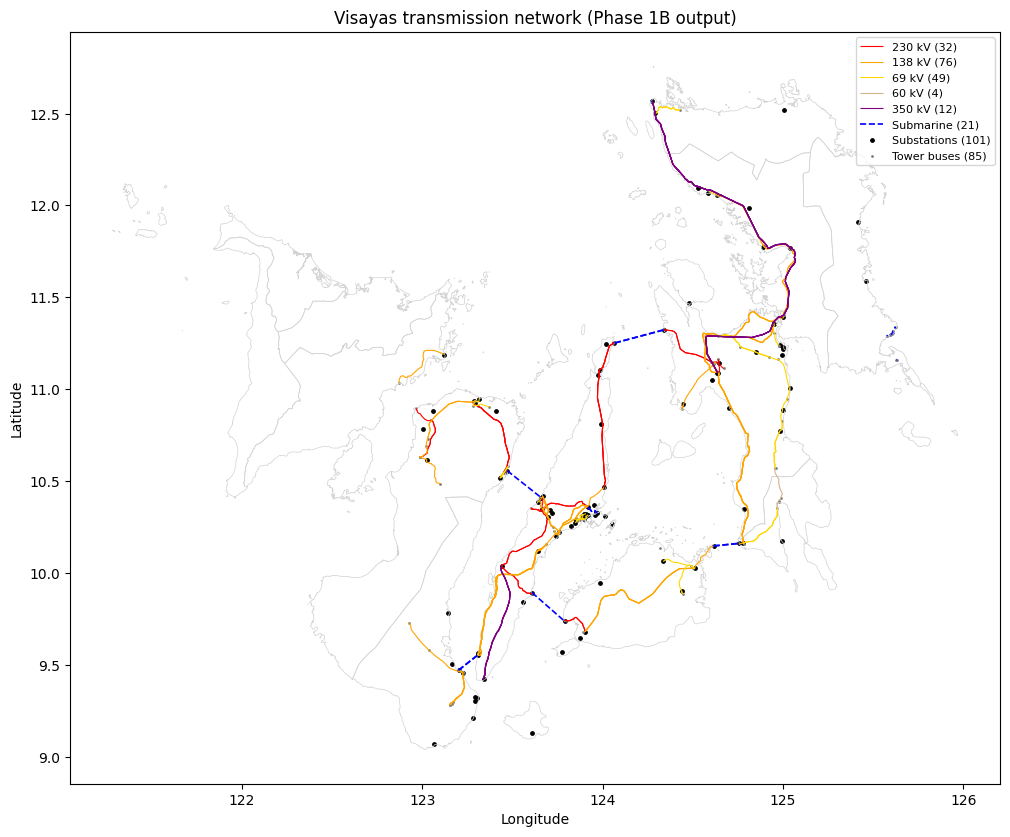

In [19]:
# Visual smoke test
import matplotlib.pyplot as plt
lines_wgs = gpd.GeoDataFrame(lines_final.join(lines_m[['geometry']]), crs=UTM).to_crs(WGS)
buses_gdf = gpd.GeoDataFrame(
    buses_final, geometry=gpd.points_from_xy(buses_final['lon'], buses_final['lat']), crs=WGS)

fig, ax = plt.subplots(figsize=(12, 10))
provinces.boundary.plot(ax=ax, color='lightgrey', linewidth=0.5)
for v, color in [(230, 'red'), (138, 'orange'), (69, 'gold'), (60, 'tan'), (350, 'purple')]:
    seg = lines_wgs[(lines_wgs['voltage_kv'] == v) & ~lines_wgs['is_submarine']]
    if len(seg):
        seg.plot(ax=ax, color=color, linewidth=0.8, label=f'{v} kV ({len(seg)})')
sub_lines = lines_wgs[lines_wgs['is_submarine']]
if len(sub_lines):
    sub_lines.plot(ax=ax, color='blue', linewidth=1.2, linestyle='--', label=f'Submarine ({len(sub_lines)})')
buses_gdf[buses_gdf['bus_type'] == 'substation'].plot(
    ax=ax, color='black', markersize=6, label=f'Substations ({n_sub})')
buses_gdf[buses_gdf['bus_type'] == 'tower'].plot(
    ax=ax, color='grey', markersize=1, label=f'Tower buses ({n_tower})')
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Visayas transmission network (Phase 1B output)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

## §13 — Save outputs

In [20]:
buses_final.to_csv(PROC_DIR / 'buses.csv', index=False)
lines_final.to_csv(PROC_DIR / 'lines.csv', index=False)
print(f'Wrote {PROC_DIR / "buses.csv"} ({len(buses_final)} rows)')
print(f'Wrote {PROC_DIR / "lines.csv"} ({len(lines_final)} rows)')

Wrote ../backend/data/processed/buses.csv (186 rows)
Wrote ../backend/data/processed/lines.csv (194 rows)
